### Import libraries and dataset

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("carclaims.csv")

In [35]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
    .str.replace(r'[^\w]', '', regex=True)
)
df.columns

Index(['month', 'weekofmonth', 'dayofweek', 'make', 'accidentarea',
       'dayofweekclaimed', 'monthclaimed', 'weekofmonthclaimed', 'sex',
       'maritalstatus', 'age', 'fault', 'policytype', 'vehiclecategory',
       'vehicleprice', 'policynumber', 'repnumber', 'deductible',
       'driverrating', 'dayspolicyaccident', 'dayspolicyclaim',
       'pastnumberofclaims', 'ageofvehicle', 'ageofpolicyholder',
       'policereportfiled', 'witnesspresent', 'agenttype',
       'numberofsuppliments', 'addresschangeclaim', 'numberofcars', 'year',
       'basepolicy', 'fraudfound'],
      dtype='object')

### Data Overview

In [36]:
print("Shape:", df.shape)
df.head()

Shape: (15420, 33)


,month,weekofmonth,dayofweek,make,accidentarea,dayofweekclaimed,monthclaimed,weekofmonthclaimed,sex,maritalstatus,...,ageofpolicyholder,policereportfiled,witnesspresent,agenttype,numberofsuppliments,addresschangeclaim,numberofcars,year,basepolicy,fraudfound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   month                15420 non-null  object
 1   weekofmonth          15420 non-null  int64 
 2   dayofweek            15420 non-null  object
 3   make                 15420 non-null  object
 4   accidentarea         15420 non-null  object
 5   dayofweekclaimed     15420 non-null  object
 6   monthclaimed         15420 non-null  object
 7   weekofmonthclaimed   15420 non-null  int64 
 8   sex                  15420 non-null  object
 9   maritalstatus        15420 non-null  object
 10  age                  15420 non-null  int64 
 11  fault                15420 non-null  object
 12  policytype           15420 non-null  object
 13  vehiclecategory      15420 non-null  object
 14  vehicleprice         15420 non-null  object
 15  policynumber         15420 non-null  int64 
 16  repn

In [38]:
df.describe()

,weekofmonth,weekofmonthclaimed,age,policynumber,repnumber,deductible,driverrating,year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


### Missing Values & Duplicates

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.isnull().sum()

month                  0
weekofmonth            0
dayofweek              0
make                   0
accidentarea           0
dayofweekclaimed       0
monthclaimed           0
weekofmonthclaimed     0
sex                    0
maritalstatus          0
age                    0
fault                  0
policytype             0
vehiclecategory        0
vehicleprice           0
policynumber           0
repnumber              0
deductible             0
driverrating           0
dayspolicyaccident     0
dayspolicyclaim        0
pastnumberofclaims     0
ageofvehicle           0
ageofpolicyholder      0
policereportfiled      0
witnesspresent         0
agenttype              0
numberofsuppliments    0
addresschangeclaim     0
numberofcars           0
year                   0
basepolicy             0
fraudfound             0
dtype: int64

<Axes: >

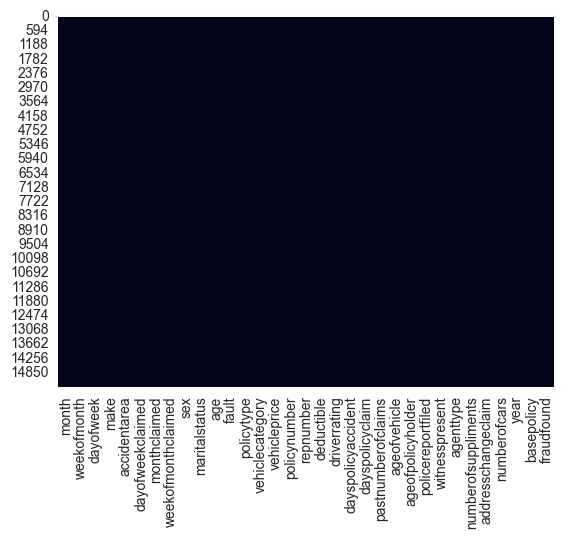

In [41]:
sns.heatmap(df.isnull(), cbar=False)

## Implicit Values

### Check Unique Values in every column

In [42]:
for col in df.columns:
    print("\n" + "="*50)
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(20))


month
Unique values: 12
month
Jan    1411
May    1367
Mar    1360
Jun    1321
Oct    1305
Dec    1285
Apr    1280
Feb    1266
Jul    1257
Sep    1240
Nov    1201
Aug    1127
Name: count, dtype: int64

weekofmonth
Unique values: 5
weekofmonth
3    3640
2    3558
4    3398
1    3187
5    1637
Name: count, dtype: int64

dayofweek
Unique values: 7
dayofweek
Monday       2616
Friday       2445
Tuesday      2300
Thursday     2173
Wednesday    2159
Saturday     1982
Sunday       1745
Name: count, dtype: int64

make
Unique values: 19
make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64

accidentarea
Unique values: 2
accidentarea
Urban    13822
Rural     1598
Name: count, dtype: 

The dataset contains no duplicates or explicit missing data across all variables. However, there are implicit missing values such as age containing 0 values.


### Specifically check unrealistic ages


In [43]:
# Create a temporary indicator
df['is_age_missing'] = (df['age'] == 0).astype(int)

# Compare fraud rates
print(df.groupby('is_age_missing')['fraudfound'].value_counts(normalize=True))


is_age_missing  fraudfound
0               No            0.940927
                Yes           0.059073
1               No            0.903125
                Yes           0.096875
Name: proportion, dtype: float64


Since fraud rate for missing ages is ~5.99%, it is almost identical to the overall dataset fraud rate (~6%). This confirms that Age = 0 is Missing Completely at Random (MCAR)

In [44]:
pd.crosstab(df["ageofpolicyholder"], df["age"])

age,0,16,17,18,19,20,21,22,23,24,...,71,72,73,74,75,76,77,78,79,80
ageofpolicyholder,,,,,,,,,,,,,,,,,,,,,
16 to 17,320,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18 to 20,0,9,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21 to 25,0,0,0,48,32,28,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26 to 30,0,0,0,0,0,0,127,125,122,135,...,0,0,0,0,0,0,0,0,0,0
31 to 35,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36 to 40,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41 to 50,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
51 to 65,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
over 65,0,0,0,0,0,0,0,0,0,0,...,40,45,32,35,34,42,29,35,20,32


In [45]:
# Check if the 'age=0' group also has other weird data
suspicious_group = df[df['age'] == 0]
print(suspicious_group['maritalstatus'].value_counts())
print(suspicious_group['vehicleprice'].value_counts())


maritalstatus
Single    320
Name: count, dtype: int64
vehicleprice
more than 69,000    318
less than 20,000      1
30,000 to 39,000      1
Name: count, dtype: int64


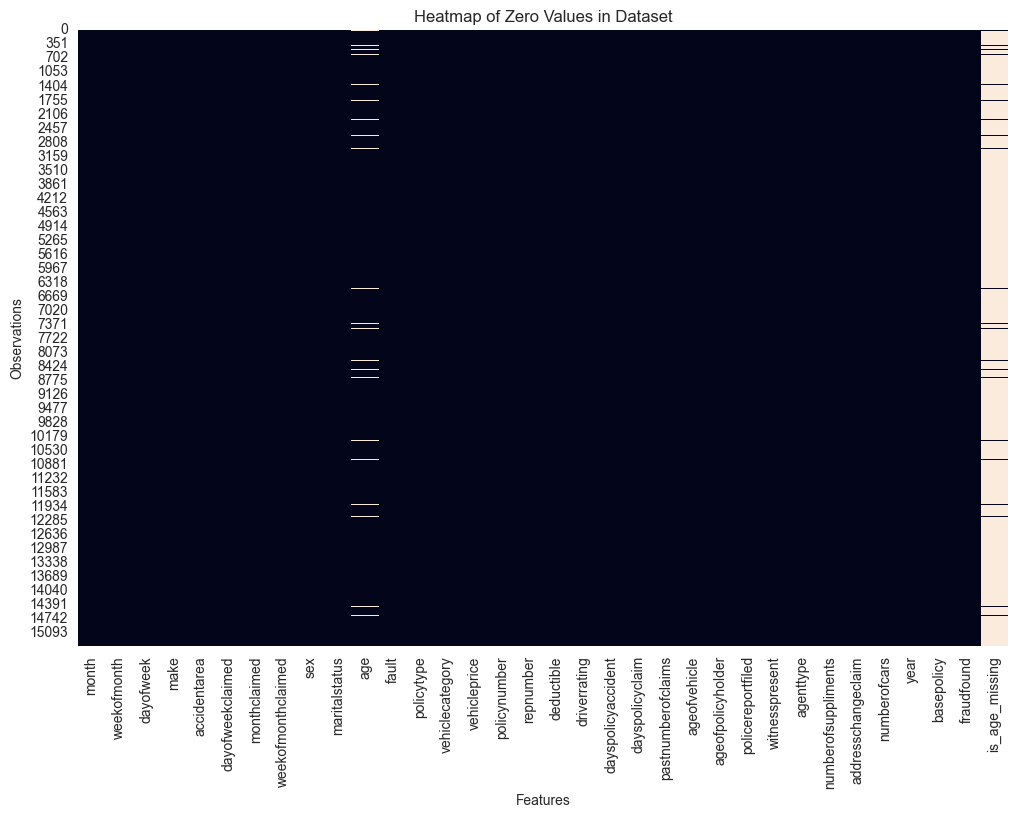

In [46]:
zero_mask = (df == 0)
plt.figure(figsize=(12,8))
sns.heatmap(zero_mask, cbar=False)
plt.title("Heatmap of Zero Values in Dataset")
plt.xlabel("Features")
plt.ylabel("Observations")
plt.show()

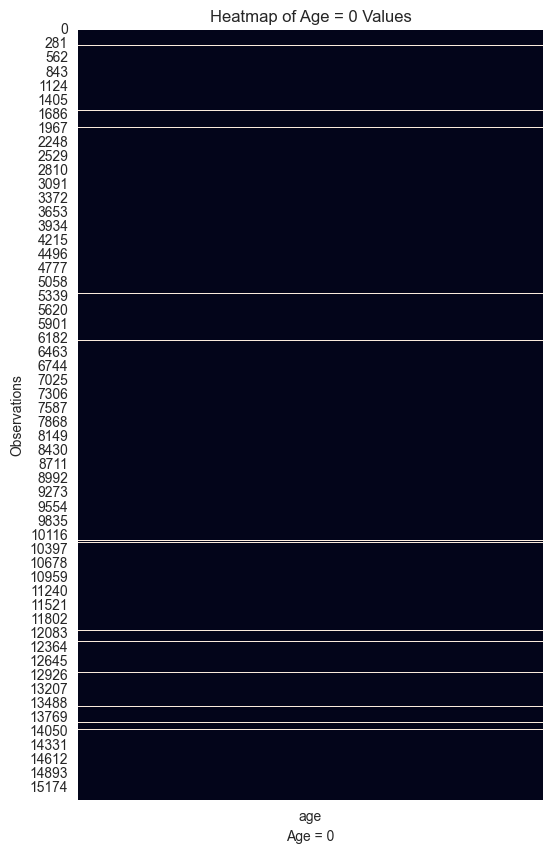

In [47]:

age_zero_mask = (df["age"] == 0)
age_zero_df = age_zero_mask.to_frame()

plt.figure(figsize=(6,10))
sns.heatmap(age_zero_df, cbar=False)
plt.title("Heatmap of Age = 0 Values")
plt.ylabel("Observations")
plt.xlabel("Age = 0")

plt.show()

In [48]:
df[df["age"] <= 0]

,month,weekofmonth,dayofweek,make,accidentarea,dayofweekclaimed,monthclaimed,weekofmonthclaimed,sex,maritalstatus,...,policereportfiled,witnesspresent,agenttype,numberofsuppliments,addresschangeclaim,numberofcars,year,basepolicy,fraudfound,is_age_missing
7,Nov,1,Friday,Honda,Urban,Tuesday,Mar,4,Male,Single,...,No,No,External,none,no change,1 vehicle,1994,Collision,No,1
13,Jan,5,Friday,Honda,Rural,Wednesday,Feb,1,Male,Single,...,No,No,External,none,no change,1 vehicle,1994,Collision,No,1
28,Jul,1,Saturday,Honda,Urban,Tuesday,Sep,4,Male,Single,...,No,No,External,none,no change,1 vehicle,1994,All Perils,Yes,1
31,Mar,1,Sunday,Honda,Urban,Tuesday,Mar,2,Male,Single,...,No,No,External,none,no change,1 vehicle,1994,Collision,No,1
58,May,1,Monday,Honda,Rural,Wednesday,May,4,Male,Single,...,No,No,External,none,no change,1 vehicle,1994,Liability,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15243,May,2,Tuesday,Honda,Urban,Monday,May,3,Male,Single,...,No,No,External,none,no change,1 vehicle,1996,Liability,No,1
15262,Mar,3,Monday,Honda,Urban,Thursday,Mar,3,Male,Single,...,No,No,External,none,no change,1 vehicle,1996,Liability,No,1
15274,Apr,3,Monday,Honda,Urban,Tuesday,May,1,Male,Single,...,No,No,External,none,no change,1 vehicle,1996,Collision,No,1
15379,Jan,2,Tuesday,Honda,Urban,Thursday,Jan,2,Male,Single,...,No,No,External,none,1 year,1 vehicle,1996,All Perils,No,1


### Count suspicious ages

In [49]:
print("Age = 0:", (df["age"] == 0).sum())
print("Age < 16:", (df["age"] < 16).sum())
print("Age > 100:", (df["age"] > 100).sum())

Age = 0: 320
Age < 16: 320
Age > 100: 0


### Check suspicious categorical labels

In [50]:
suspicious_words = ["unknown", "none", "missing", "na", "n/a", "other", "?"]

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    values = df[col].astype(str).str.lower().unique()
    suspicious_found = [v for v in values if v in suspicious_words]

    if suspicious_found:
        print(col, ":", suspicious_found)

dayspolicyaccident : ['none']
dayspolicyclaim : ['none']
pastnumberofclaims : ['none']
numberofsuppliments : ['none']


### Check low-variance columns

In [51]:
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100

    if top_freq > 95:
        print(f"{col}: top category/value = {top_freq:.2f}%")

deductible: top category/value = 96.23%
dayspolicyaccident: top category/value = 98.88%
dayspolicyclaim: top category/value = 99.49%
policereportfiled: top category/value = 97.22%
witnesspresent: top category/value = 99.44%
agenttype: top category/value = 98.44%
is_age_missing: top category/value = 97.92%


### Check ID-like columns


In [52]:
for col in df.columns:
    unique_ratio = df[col].nunique() / len(df)

    if unique_ratio > 0.90:
        print(f"{col}: possible ID column, unique ratio = {unique_ratio:.2f}")

policynumber: possible ID column, unique ratio = 1.00


### Check fraud rate by important “No/Yes” variables


In [53]:
important_binary_cols = ["policereportfiled","witnesspresent"]

for col in important_binary_cols:
    print("\n" + "="*50)
    print(col)
    print(pd.crosstab(df[col], df["fraudfound"], normalize="index") * 100)


policereportfiled
fraudfound                No       Yes
policereportfiled                     
No                 93.950107  6.049893
Yes                96.261682  3.738318

witnesspresent
fraudfound             No       Yes
witnesspresent                     
No              93.999870  6.000130
Yes             96.551724  3.448276


### Check inconsistent or suspicious combinations

In [54]:
df[df["age"] < 16][["age", "fraudfound", "policytype", "vehiclecategory"]].head(20)

,age,fraudfound,policytype,vehiclecategory
7,0,No,Sport - Collision,Sport
13,0,No,Sedan - Collision,Sedan
28,0,Yes,Sedan - All Perils,Sedan
31,0,No,Sedan - Collision,Sedan
58,0,No,Sedan - Liability,Sport
62,0,No,Sedan - All Perils,Sedan
84,0,No,Sedan - Liability,Sport
119,0,Yes,Sedan - All Perils,Sedan
120,0,No,Sedan - All Perils,Sedan
161,0,No,Sedan - Liability,Sport


### Create a summary table of possible implicit issues


In [55]:
implicit_issues = []
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in df.columns:
    unique_count = df[col].nunique()
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100
    unique_ratio = unique_count / len(df)
    issue = []

    if top_freq > 95:
        issue.append("Low variance")

    if unique_ratio > 0.90:
        issue.append("Possible ID")

    if col in numeric_cols:
        if (df[col] == 0).sum() > 0:
            issue.append("Contains zero values")
        if (df[col] < 0).sum() > 0:
            issue.append("Contains negative values")

    if issue:
        implicit_issues.append({
            "column": col,
            "unique_values": unique_count,
            "top_value_percentage": round(top_freq, 2),
            "unique_ratio": round(unique_ratio, 2),
            "possible_issue": ", ".join(issue)})

implicit_issues_df = pd.DataFrame(implicit_issues)
implicit_issues_df

,column,unique_values,top_value_percentage,unique_ratio,possible_issue
0,age,66,3.87,0.0,Contains zero values
1,policynumber,15420,0.01,1.0,Possible ID
2,deductible,4,96.23,0.0,Low variance
3,dayspolicyaccident,5,98.88,0.0,Low variance
4,dayspolicyclaim,4,99.49,0.0,Low variance
5,policereportfiled,2,97.22,0.0,Low variance
6,witnesspresent,2,99.44,0.0,Low variance
7,agenttype,2,98.44,0.0,Low variance
8,is_age_missing,2,97.92,0.0,"Low variance, Contains zero values"


## Fraud Count and Percentage

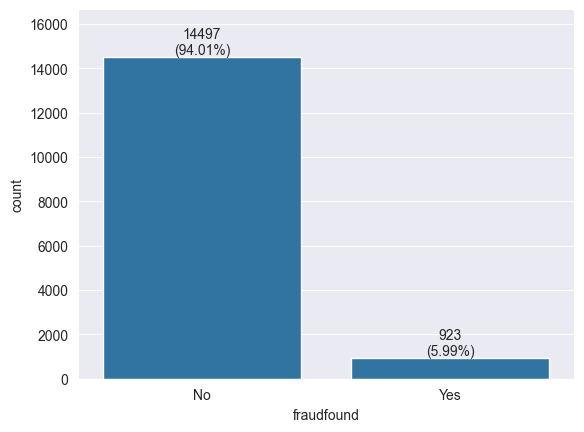

In [56]:
ax = sns.countplot(x="fraudfound", data=df)
total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
ax.set_ylim(0, max(df["fraudfound"].value_counts()) * 1.15)

plt.show()

### Univariate analysis

array([[<Axes: title={'center': 'weekofmonth'}>,
        <Axes: title={'center': 'weekofmonthclaimed'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'policynumber'}>,
        <Axes: title={'center': 'repnumber'}>,
        <Axes: title={'center': 'deductible'}>],
       [<Axes: title={'center': 'driverrating'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'is_age_missing'}>]], dtype=object)

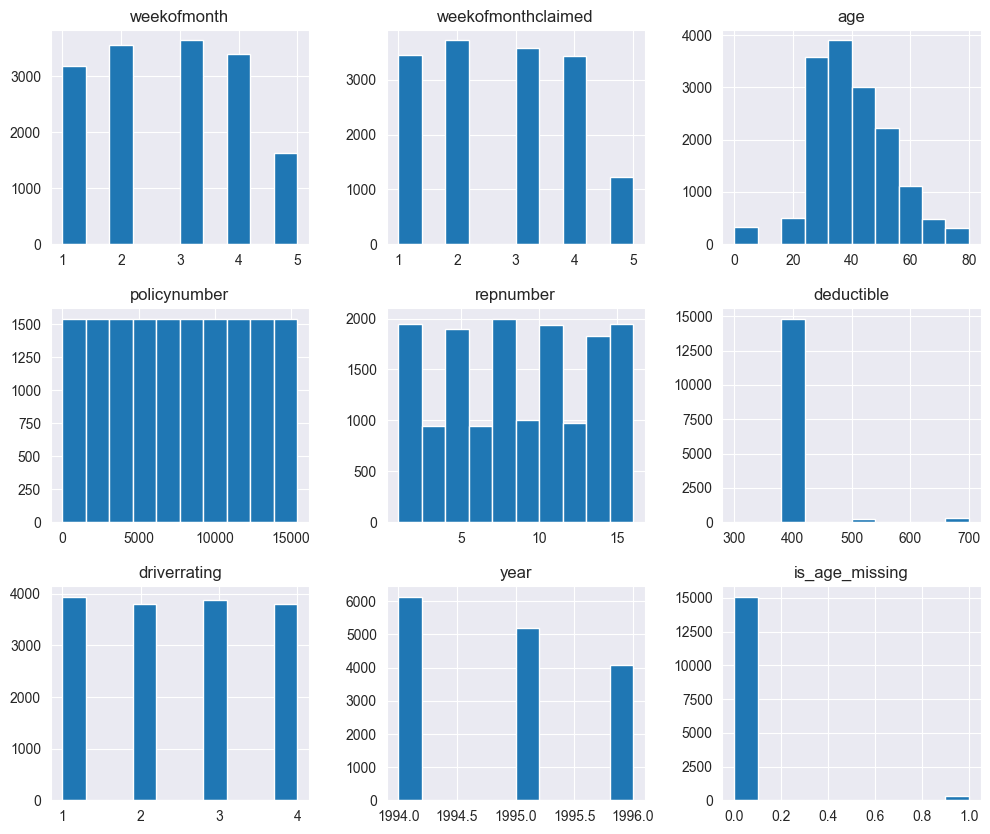

In [57]:
df.hist(figsize=(12,10))

The target variable, “fraudfound” indicates whether an insurance claim is fraudulent, described through a binary categorical variable with two classes: “Yes” (fraudulent claim) amounting to 94.01%(14,497 records) and “No” (non-fraudulent claim). Only  5.99%  (923 records) are fraudulent. This indicates that the dataset is imbalanced.

This will be a significant challenge for classification and  machine learning models as they tend to be biased towards the majority class. Accuracy alone won’t be an appropriate evaluation metric for this project. Metrics such as recall , precision, and F1 score can help. The class imbalance motivates us to use resampling methods like oversampling or SMOTE.


In [58]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print()
print("Categorical columns:", cat_cols)

Numerical columns: ['weekofmonth', 'weekofmonthclaimed', 'age', 'policynumber', 'repnumber', 'deductible', 'driverrating', 'year', 'is_age_missing']

Categorical columns: ['month', 'dayofweek', 'make', 'accidentarea', 'dayofweekclaimed', 'monthclaimed', 'sex', 'maritalstatus', 'fault', 'policytype', 'vehiclecategory', 'vehicleprice', 'dayspolicyaccident', 'dayspolicyclaim', 'pastnumberofclaims', 'ageofvehicle', 'ageofpolicyholder', 'policereportfiled', 'witnesspresent', 'agenttype', 'numberofsuppliments', 'addresschangeclaim', 'numberofcars', 'basepolicy', 'fraudfound']


1. week of month and week of month claimed take discrete values from 1 to 5. Most observations fall within 1 to 4, but 5 is less frequent as a smaller number of days at the end of longer months.
2. Age variable shows a bell-shaped distribution centered around the middle-aged individuals between 30 to 50 years old.
3. Policy numbers function as a unique identifier and display a uniform distribution. The rep number variable appears evely distributed a swell.
4. The deductible is concentred around 400 that indicates low variability and low discriminatory power
5. Driver rating distribution is evenly balanced


### Categorical Feature Distributions

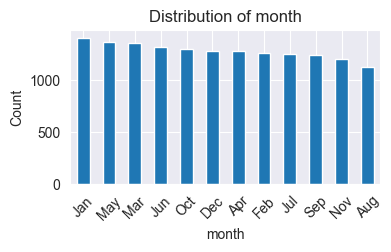

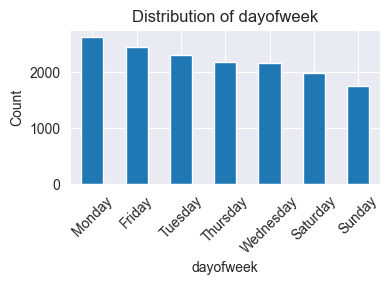

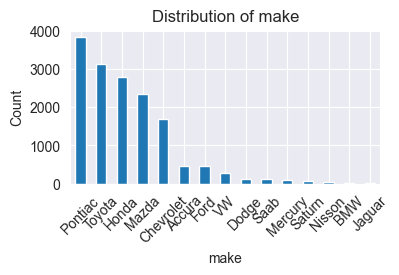

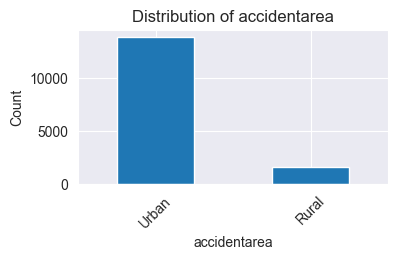

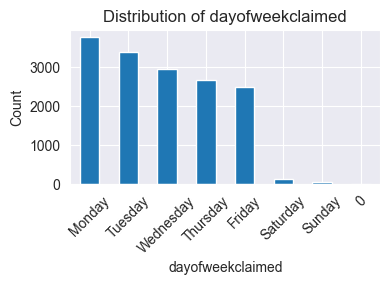

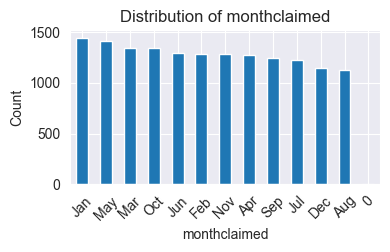

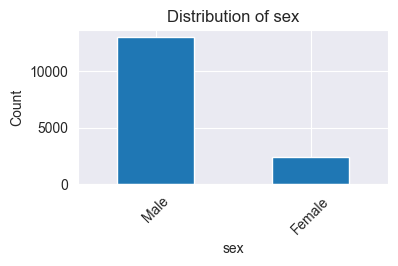

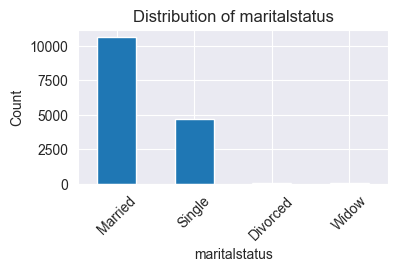

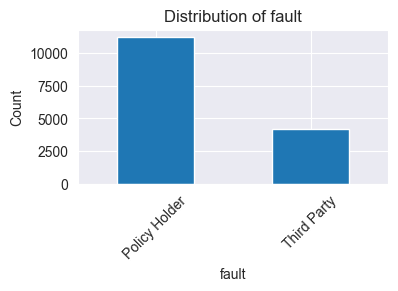

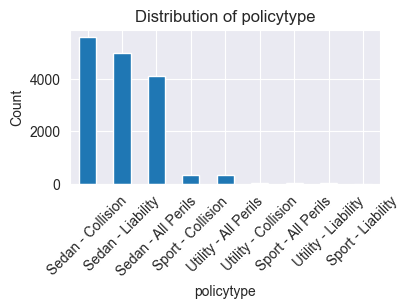

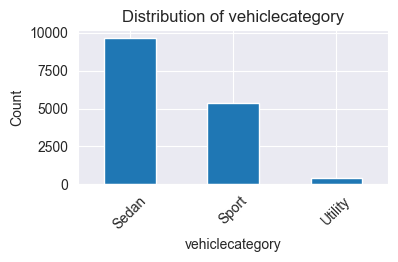

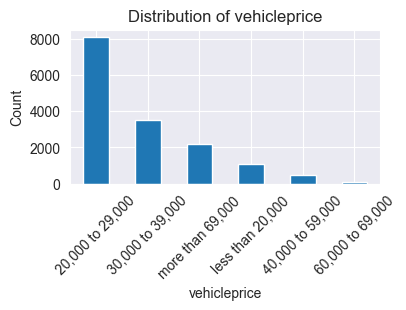

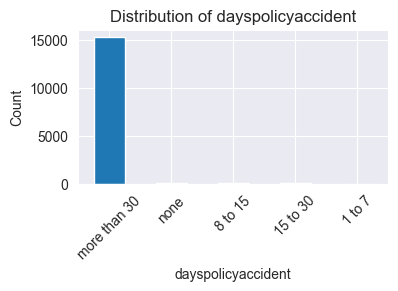

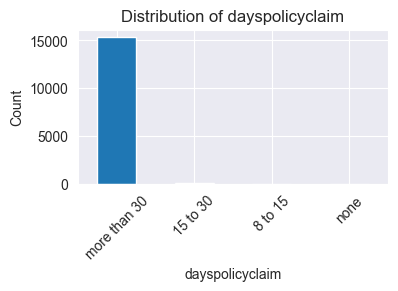

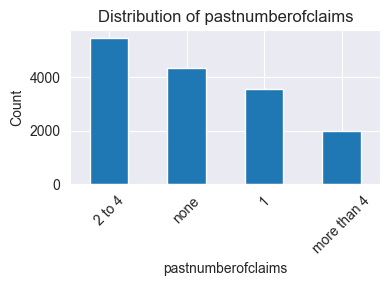

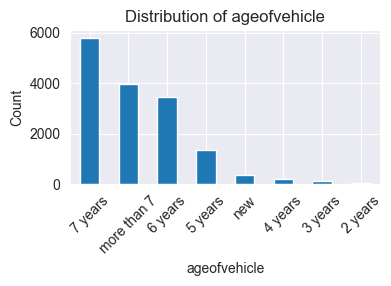

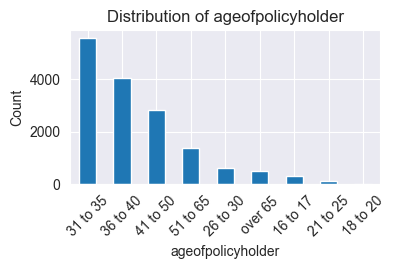

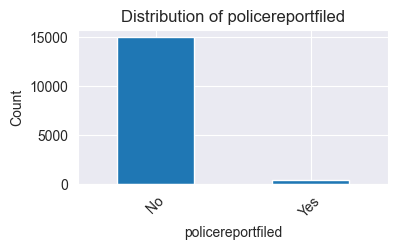

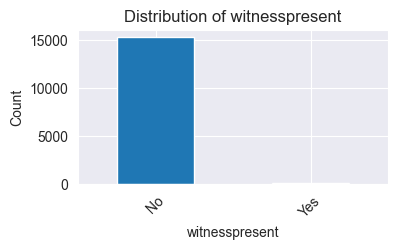

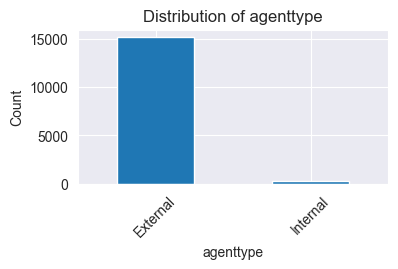

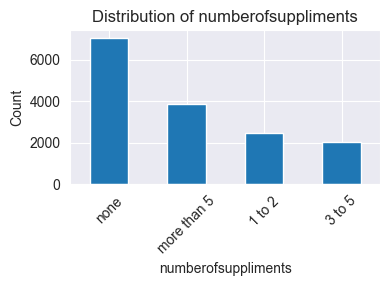

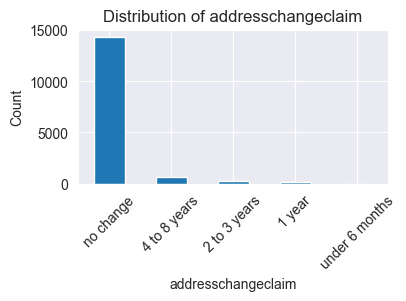

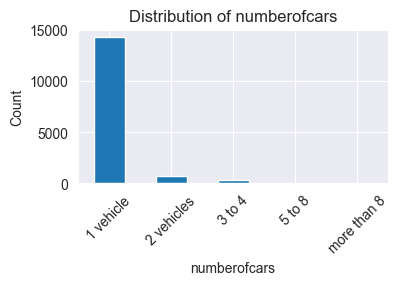

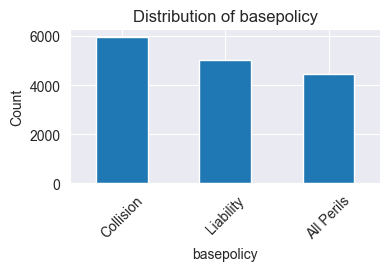

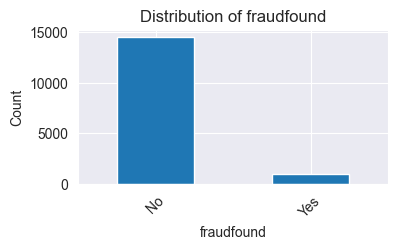

In [59]:
for col in cat_cols:
    plt.figure(figsize=(4, 2))
    df[col].value_counts().head(15).plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

1. **Month:** This categorical variable appears to be relatively evenly distributed across all months.

2. **Days of the Week:** This variable is also fairly balanced across the days of the week, although weekdays appear slightly more frequent than weekends.

3. **Make:** The distribution of vehicle brands is not evenly sampled. Brands such as Toyota, Honda, and Mazda appear much more frequently than smaller-volume manufacturers.

4. **Accident Area:** Most claims occur in urban areas rather than rural areas, showing a strong class imbalance.

5. **Day of Week Claimed:** Claims are more concentrated during weekdays. The variable also contains an anomalous category (“0”) that should be handled during preprocessing.

6. **Month Claimed:** The distribution is relatively uniform across months, suggesting no strong seasonal variation. However, the anomalous category (“0”) should also be addressed.

7. **Sex:** Male policyholders constitute the majority of observations in the dataset.

8. **Marital Status:** Most claimants are either married or single, while divorced and widowed categories contain very few observations.

9. **Fault:** The majority of claims are attributed to the policyholder, while a smaller portion involves third parties.

10. **Policy Type:** This variable shows a highly uneven distribution across categories, with policies concentrated mainly among sedan vehicles.

11. **Vehicle Category:** There is a strong imbalance across categories. Sedan vehicles dominate the dataset, followed by sports vehicles.

12. **Vehicle Price:** Most vehicles fall within the lower to mid-range price categories, particularly in the “20,000 to 29,000” range.

13. **Days Policy Accident:** This variable is extremely skewed, with most observations falling into the “more than 30 days” category.

14. **Days Policy Claim:** Similar to the previous variable, this distribution is highly skewed toward the “more than 30 days” category.

15. **Past Number of Claims:** Most claimants have a history of “2 to 4 claims,” followed by those with no prior claims. This variable may provide valuable predictive information.

16. **Age of Vehicle:** Older vehicles appear more frequently in the dataset compared to newer vehicles.

17. **Age of Policy Holder:** The majority of claimants are middle-aged, particularly between 31 and 50 years old.

18. **Police Report Filed:** This variable is highly imbalanced, with most claims not involving a police report. Although it has low variance, it may still be an important indicator of claim legitimacy or seriousness.

19. **Witness Present:** This variable is also highly imbalanced, as most claims report no witnesses present. Despite this skewness, it could still provide useful information regarding claim credibility.

20. **Agent Type:** The distribution is strongly imbalanced, with most policies handled by external agents. Differences in claim practices between internal and external agents may contain informative patterns.

21. **Number of Supplements:** The largest proportion of claims contains no supplementary documentation, although the variable still shows moderate variation across categories.

22. **Address Change Claim:** This variable is highly imbalanced, as most policyholders report no address changes. The skewed distribution suggests low variability.

23. **Number of Cars:** This variable is also highly skewed, with the majority of policyholders owning only one vehicle.

24. **Base Policy:** This variable shows a relatively more balanced distribution across categories and is likely to provide useful information during model training.


### Fraud vs Non-Fraud: Important Categorical Comparisons

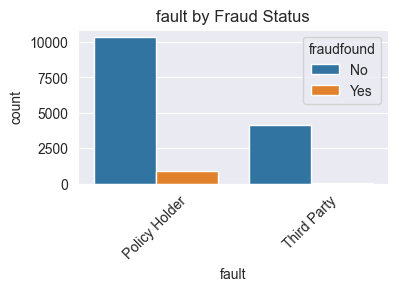

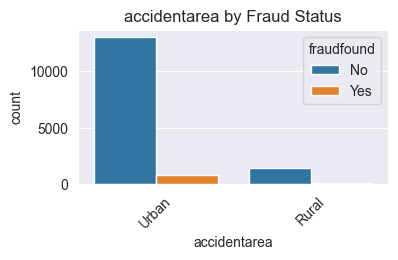

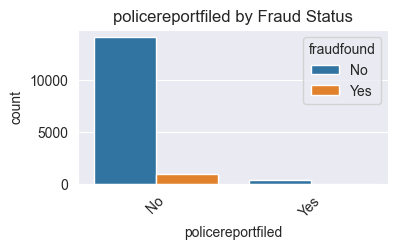

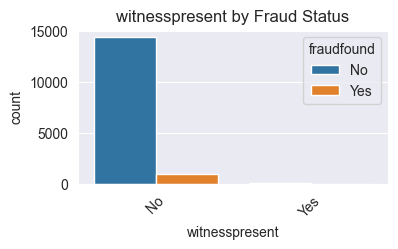

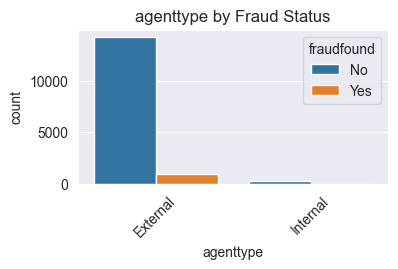

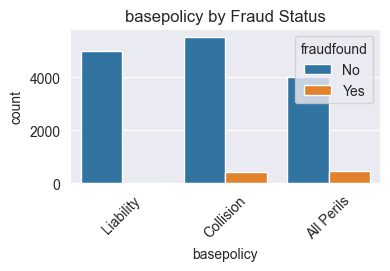

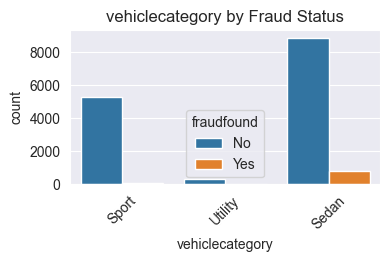

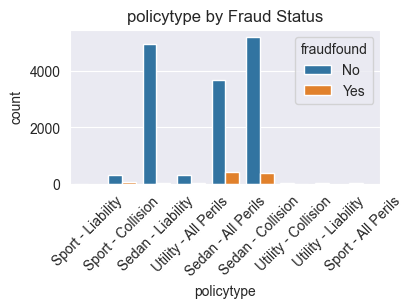

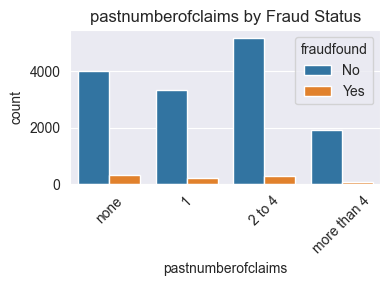

In [60]:

important_cat_cols = [
    "fault",
    "accidentarea",
    "policereportfiled",
    "witnesspresent",
    "agenttype",
    "basepolicy",
    "vehiclecategory",
    "policytype",
    "pastnumberofclaims"
]

for col in important_cat_cols:
    if col in df.columns:
        plt.figure(figsize=(4, 2))
        sns.countplot(data=df, x=col, hue="fraudfound")
        plt.title(f"{col} by Fraud Status")
        plt.xticks(rotation=45)
        plt.show()

This visually spots whether certain important categories have a noticeably higher proportion of fraud. It visualizes and features the distribution and target imbalance.


1. **Fault:** Fraud cases occur almost exclusively when the policyholder is at fault. This suggests that the variable may have predictive importance for fraud detection.

2. **Accident Area:** Fraudulent claims occur mostly in urban areas. However, since legitimate claims are also concentrated in urban regions, this variable may not strongly distinguish fraud from non-fraud cases.

3. **Police Report Filed:** Both fraudulent and legitimate claimants often do not file police reports. Therefore, this variable may not provide strong discriminatory power for fraud detection.

4. **Witness Present:** The majority of observations in both fraud and non-fraud groups fall under the “No” category. This makes the variable a relatively weak predictor.

5. **Agent Type:** External agents handle most claims in the dataset. Based on the visual distribution alone, it is difficult to conclude whether agent type directly influences fraud likelihood.

6. **Liability:** Fraud cases are almost nonexistent within liability claims, suggesting that this category may have low fraud risk.

7. **Vehicle Category:** Sedan vehicles show the highest number of fraudulent claims, while utility vehicles appear minimally represented. However, sedan vehicles are also the most common category overall, so this alone does not imply causation.

8. **Policy Type:** Sedan collision and sedan all-perils policies show the highest number of fraudulent claims. However, this visualization largely reflects the combined information already present in vehicle category and policy type distributions, making the chart somewhat redundant.

9. **Past Number of Claims:** The distribution of fraud appears relatively similar across all categories. This suggests that the number of previous claims may not strongly influence fraudulent behavior.

### Numerical Features vs Fraud

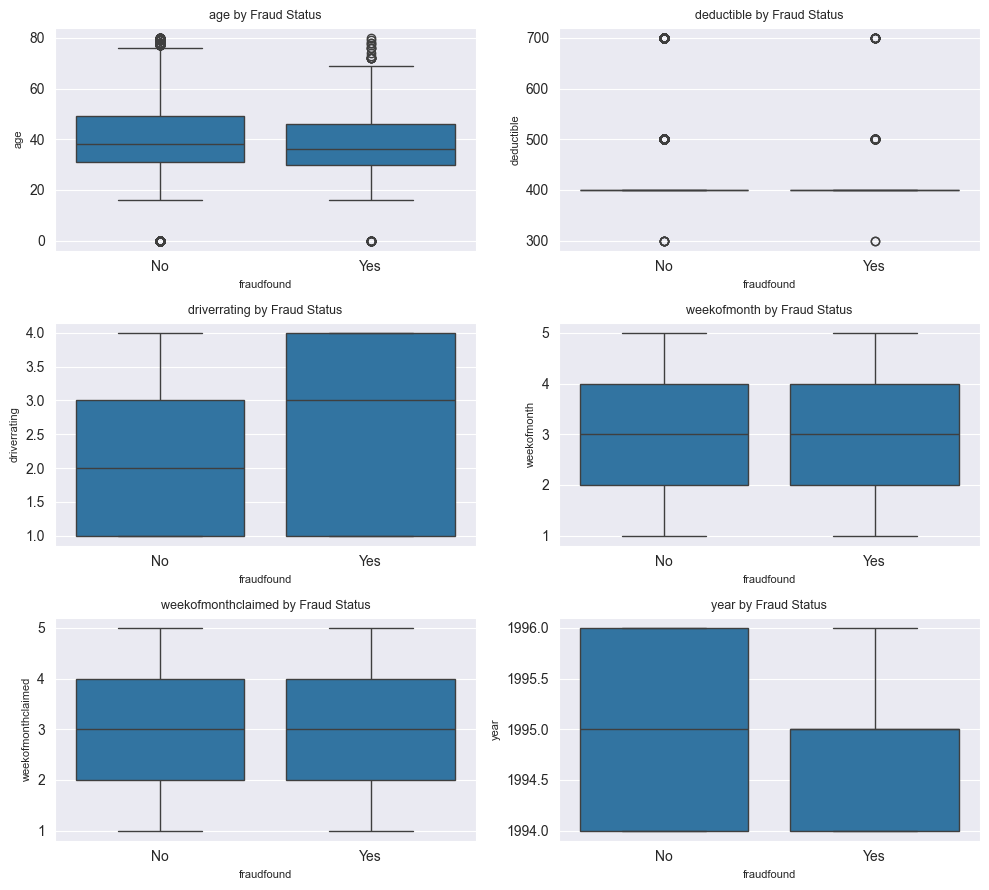

In [61]:
important_num_cols = [
    "age",
    "deductible",
    "driverrating",
    "weekofmonth",
    "weekofmonthclaimed",
    "year"
]

n_cols = 2
n_rows = (len(important_num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(important_num_cols):
    if col in df.columns:
        sns.boxplot(data=df, x="fraudfound", y=col, ax=axes[i])
        axes[i].set_title(f"{col} by Fraud Status", fontsize=9)
        axes[i].set_xlabel("fraudfound", fontsize=8)
        axes[i].set_ylabel(col, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

For each numerical column, the box shows if they have a noticeably different distribution than legitimate.

1. **Age:** The distributions of fraudulent and non-fraudulent claims appear almost identical. This suggests that age alone does not provide meaningful information for distinguishing fraud.

2. **Deductible:** Both fraud and non-fraud groups show nearly identical distributions, centered around a deductible value of 400, with similar outliers at 300, 500, and 700. This indicates that deductible amount is unlikely to be useful for prediction.

3. **Driver Rating:** Legitimate claims are more concentrated around driver rating 2, while fraudulent claims appear slightly more concentrated around rating 3. This may suggest that higher-risk drivers are somewhat more associated with fraud.

4. **Week of Month:** The distributions for fraudulent and non-fraudulent claims appear almost identical, suggesting little predictive value.

5. **Week of Month Claimed:** Both groups again show very similar distributions, indicating that this variable is unlikely to contribute meaningful information for fraud detection.

6. **Year:** Legitimate claims span all three years (1994–1996), while fraudulent claims appear more concentrated around 1994–1995, resulting in a narrower distribution for fraud cases. This may reflect either a genuine temporal pattern or a characteristic of the data collection process.


### Grouped Summary by Target

#### Mean

In [62]:
df.groupby("fraudfound")[num_cols].mean()

,weekofmonth,weekofmonthclaimed,age,policynumber,repnumber,deductible,driverrating,year,is_age_missing
fraudfound,,,,,,,,,
No,2.792440,2.695799,39.956957,7733.351038,8.492033,407.511899,2.485756,1994.871491,0.019935
Yes,2.728061,2.665222,38.265439,7351.592633,8.345612,410.725894,2.520043,1994.787649,0.033586


#### Median

In [63]:
df.groupby("fraudfound")[num_cols].median()

,weekofmonth,weekofmonthclaimed,age,policynumber,repnumber,deductible,driverrating,year,is_age_missing
fraudfound,,,,,,,,,
No,3.0,3.0,38.0,7755.0,8.0,400.0,2.0,1995.0,0.0
Yes,3.0,3.0,36.0,7019.0,8.0,400.0,3.0,1995.0,0.0


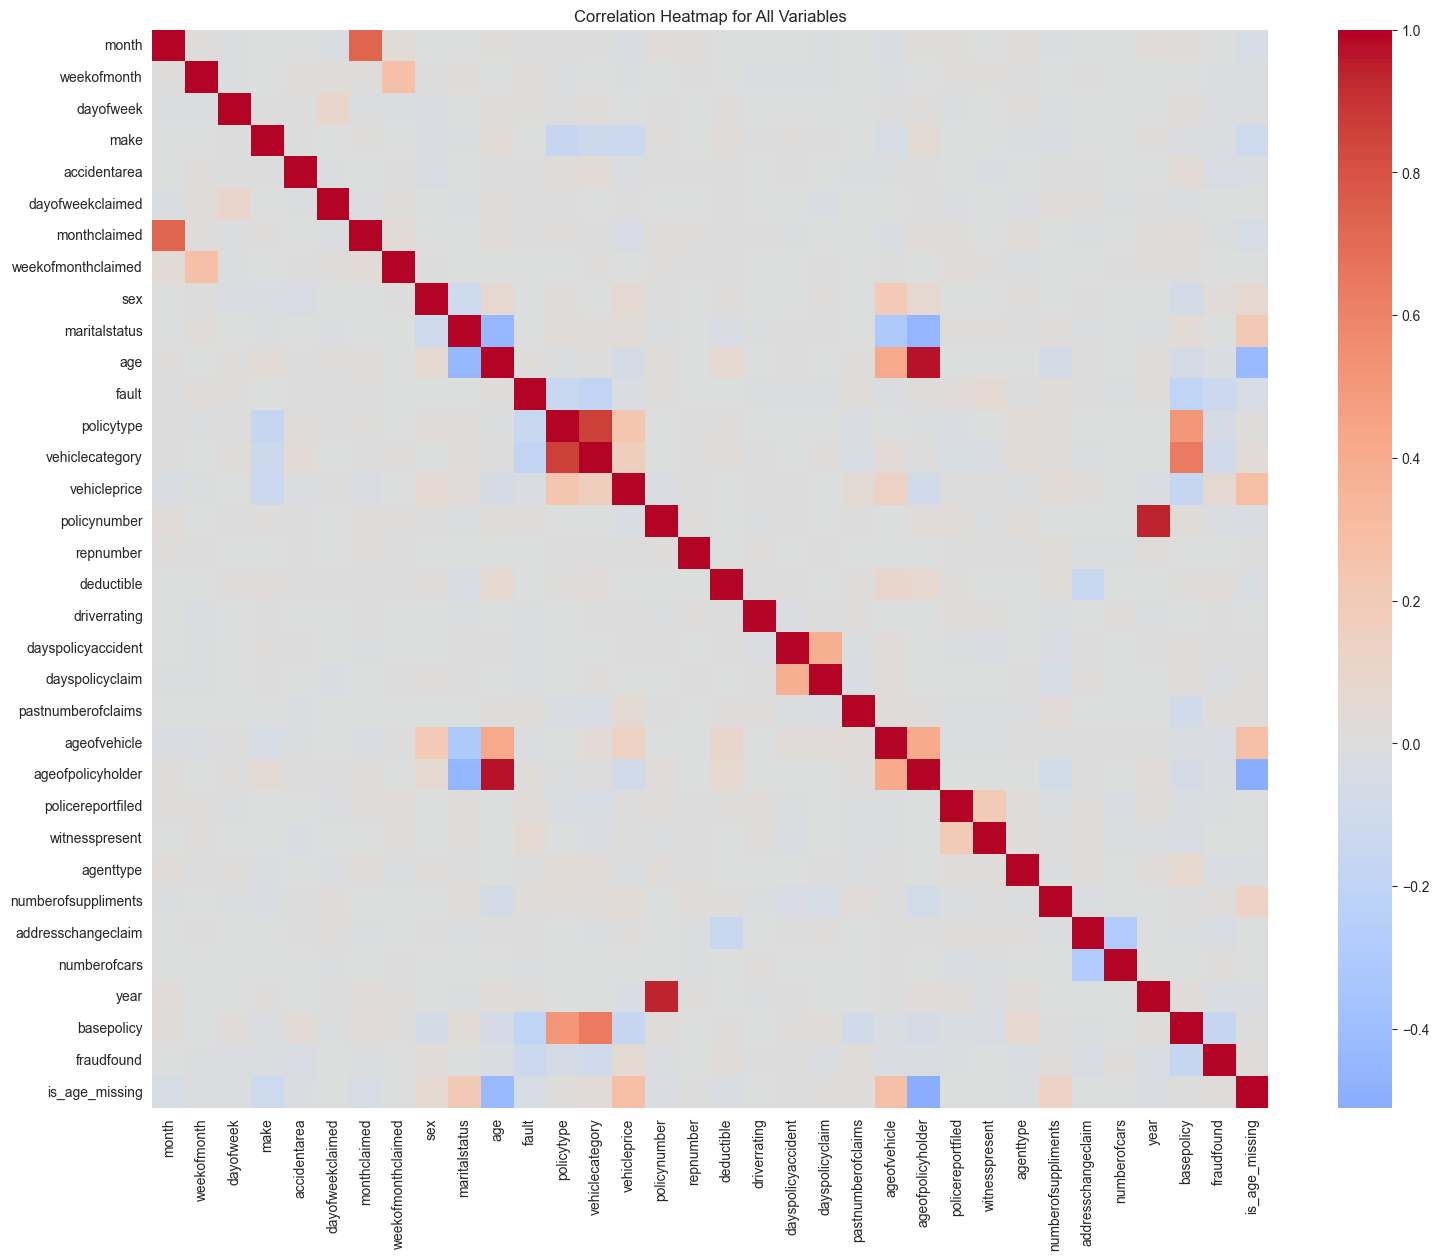

Correlation with fraudfound:
fraudfound             1.000000
vehicleprice           0.061541
sex                    0.029953
pastnumberofclaims     0.023363
is_age_missing         0.022716
deductible             0.017348
numberofsuppliments    0.013264
numberofcars           0.009109
driverrating           0.007266
dayspolicyaccident     0.005529
maritalstatus          0.000568
dayofweekclaimed      -0.002065
weekofmonthclaimed    -0.005761
repnumber             -0.007551
witnesspresent        -0.008057
month                 -0.008670
monthclaimed          -0.010247
weekofmonth           -0.011861
dayspolicyclaim       -0.015400
policereportfiled     -0.016007
dayofweek             -0.017456
make                  -0.019187
policynumber          -0.020345
ageofvehicle          -0.022236
agenttype             -0.022978
year                  -0.024760
age                   -0.029741
ageofpolicyholder     -0.031966
accidentarea          -0.033499
addresschangeclaim    -0.037640
policytype 

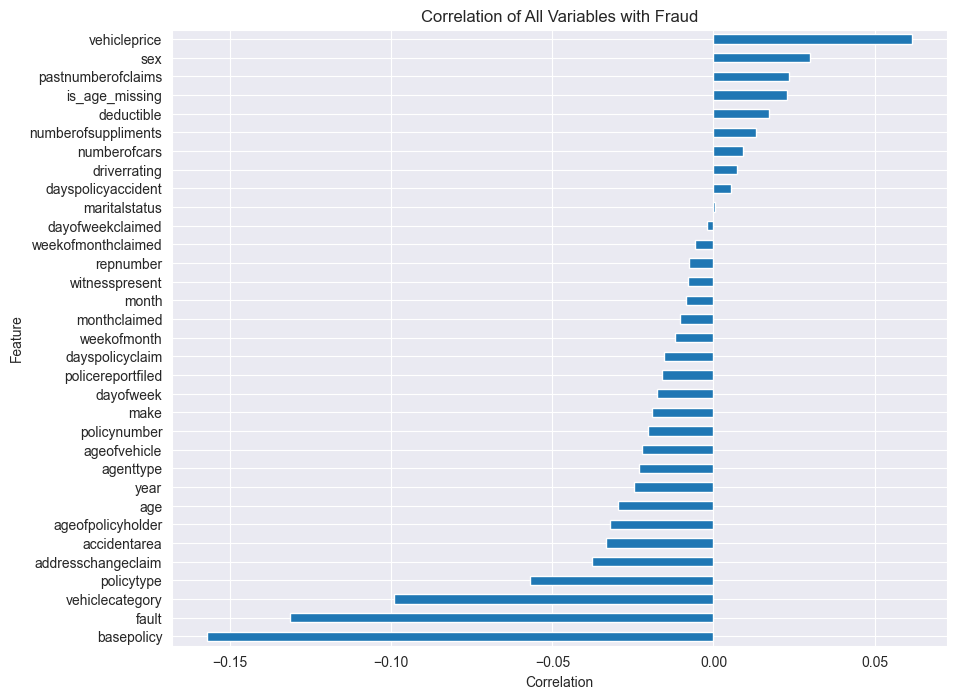


Fraud Rate by Category for Categorical Variables

month
fraudfound         No       Yes
month                          
Apr         93.750000  6.250000
Aug         92.546584  7.453416
Dec         95.175097  4.824903
Feb         93.522907  6.477093
Jan         93.834160  6.165840
Jul         95.226730  4.773270
Jun         93.943982  6.056018
Mar         92.500000  7.500000
May         93.123628  6.876372
Nov         96.169858  3.830142
Oct         94.636015  5.363985
Sep         93.870968  6.129032

dayofweek
fraudfound         No       Yes
dayofweek                      
Friday      93.701431  6.298569
Monday      93.883792  6.116208
Saturday    93.340061  6.659939
Sunday      93.008596  6.991404
Thursday    94.477681  5.522319
Tuesday     94.782609  5.217391
Wednesday   94.673460  5.326540

make
fraudfound          No        Yes
make                             
Accura       87.500000  12.500000
BMW          93.333333   6.666667
Chevrolet    94.408090   5.591910
Dodge        98.1651

,feature,absolute_correlation_with_fraud
0,basepolicy,0.157079
1,fault,0.131389
2,vehiclecategory,0.099198
3,vehicleprice,0.061541
4,policytype,0.057057
5,addresschangeclaim,0.037640
6,accidentarea,0.033499
7,ageofpolicyholder,0.031966
8,sex,0.029953
9,age,0.029741


In [64]:
# ============================================================
# Correlation + Fraud Rate Analysis for ALL Variables
# Vehicle Insurance Fraud Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# ------------------------------
# 1. Copy dataframe
# ------------------------------
df_corr = df.copy()

# ------------------------------
# 2. Encode target variable
# ------------------------------
df_corr["fraudfound"] = df_corr["fraudfound"].map({"No": 0, "Yes": 1})

# ------------------------------
# 3. Encode all categorical variables
# ------------------------------
cat_cols = df_corr.select_dtypes(include="object").columns

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))
    label_encoders[col] = le

# ------------------------------
# 4. Correlation matrix for all variables
# ------------------------------
corr_matrix = df_corr.corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for All Variables")
plt.show()

# ------------------------------
# 5. Correlation with target variable
# ------------------------------
target_corr = corr_matrix["fraudfound"].sort_values(ascending=False)

print("Correlation with fraudfound:")
print(target_corr)

plt.figure(figsize=(10, 8))
target_corr.drop("fraudfound").sort_values().plot(kind="barh")
plt.title("Correlation of All Variables with Fraud")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

# ------------------------------
# 6. Fraud rate by category for all categorical variables
#    This is more interpretable than label correlation
# ------------------------------
df_original = df.copy()

print("\nFraud Rate by Category for Categorical Variables")

for col in df_original.select_dtypes(include="object").columns:
    if col != "fraudfound":
        print("\n" + "="*60)
        print(col)
        print(pd.crosstab(
            df_original[col],
            df_original["fraudfound"],
            normalize="index"
        ) * 100)

# ------------------------------
# 7. Mean fraud rate by numerical variables
#    For numeric variables, group into bins
# ------------------------------
num_cols = df_original.select_dtypes(include=["int64", "float64"]).columns

print("\nFraud Rate by Numerical Feature Bins")

for col in num_cols:
    if col != "fraudfound":
        print("\n" + "="*60)
        print(col)

        try:
            temp = df_original[[col, "fraudfound"]].copy()
            temp["bin"] = pd.qcut(temp[col], q=5, duplicates="drop")

            print(pd.crosstab(
                temp["bin"],
                temp["fraudfound"],
                normalize="index"
            ) * 100)

        except Exception as e:
            print(f"Could not bin {col}: {e}")

# ------------------------------
# 8. Summary table: absolute correlation with fraud
# ------------------------------
corr_summary = (
    target_corr
    .drop("fraudfound")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)

corr_summary.columns = ["feature", "absolute_correlation_with_fraud"]

corr_summary

In [65]:
# Check variance / imbalance for categorical columns
variance_summary = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True).max()

    variance_summary.append({
        "feature": col,
        "top_category_percentage": round(top_freq * 100, 2),
        "unique_values": df[col].nunique()
    })

variance_df = pd.DataFrame(variance_summary)

# Define low variance as one category taking more than 95% of values
low_variance_cols = variance_df[variance_df["top_category_percentage"] > 95]

# High / usable variance columns
high_variance_cols = variance_df[variance_df["top_category_percentage"] <= 95]

print("Low variance columns:", len(low_variance_cols))
print("High / usable variance columns:", len(high_variance_cols))

display(variance_df.sort_values("top_category_percentage", ascending=False))

Low variance columns: 7
High / usable variance columns: 27


,feature,top_category_percentage,unique_values
20,dayspolicyclaim,99.49,4
25,witnesspresent,99.44,2
19,dayspolicyaccident,98.88,5
26,agenttype,98.44,2
33,is_age_missing,97.92,2
24,policereportfiled,97.22,2
17,deductible,96.23,4
32,fraudfound,94.01,2
28,addresschangeclaim,92.89,5
29,numberofcars,92.84,5
